# Experiment Result Visualization

This notebook loads `acc.csv`, `spearman.csv`, and `time.csv` from `src/result/` and visualizes:

- Accuracy heatmaps
- Spearman correlation heatmaps
- Runtime comparison plots


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 200

METHOD_ORDER = ["EXACT", "BP", "RK", "ABRA", "SILVAN", "GPU_SIR_BRIDGE"]
APPROX_METHOD_ORDER = METHOD_ORDER[1:]
SOURCE_ORDER = ["real", "synthetic"]
SOURCE_TITLE = {"real": "Real graphs", "synthetic": "Synthetic graphs"}

candidate_dirs = [Path.cwd() / "result", Path.cwd() / "src" / "result"]
RESULT_DIR = next((path for path in candidate_dirs if path.exists()), None)
if RESULT_DIR is None:
    raise FileNotFoundError("Could not find result directory. Run this notebook from repo root or src/.")

FIG_DIR = RESULT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

acc_df = pd.read_csv(RESULT_DIR / "acc.csv")
spearman_df = pd.read_csv(RESULT_DIR / "spearman.csv")
time_df = pd.read_csv(RESULT_DIR / "time.csv")

print(f"Result directory: {RESULT_DIR}")
print(f"Figures will be saved to: {FIG_DIR}")
print(f"acc rows: {len(acc_df)}, spearman rows: {len(spearman_df)}, time rows: {len(time_df)}")


Result directory: /home/zjy/project/FastBC/src/result
Figures will be saved to: /home/zjy/project/FastBC/src/result/figures
acc rows: 21, spearman rows: 756, time rows: 21


In [2]:
def add_dataset_label(df: pd.DataFrame) -> pd.DataFrame:
    labeled = df.copy()
    labeled["dataset_label"] = labeled["graph_source"].str.capitalize() + " / " + labeled["graph_name"]
    labeled["source_rank"] = labeled["graph_source"].map({"real": 0, "synthetic": 1}).fillna(99)
    return labeled


def ordered_dataset_labels(df: pd.DataFrame) -> list[str]:
    ordered = (
        add_dataset_label(df)[["dataset_label", "graph_source", "graph_name", "num_nodes", "source_rank"]]
        .drop_duplicates()
        .sort_values(["source_rank", "num_nodes", "graph_name"])
    )
    return ordered["dataset_label"].tolist()


def plot_split_heatmaps(df: pd.DataFrame, columns: list[str], title: str, cmap: str, vmin=None, vmax=None, fmt: str = ".2f", cbar_label: str | None = None):
    labeled = add_dataset_label(df)
    ordered_labels = ordered_dataset_labels(df)
    max_rows = max((labeled["graph_source"] == source).sum() for source in SOURCE_ORDER)
    fig_height = max(4.5, 0.55 * max_rows)
    fig, axes = plt.subplots(1, 2, figsize=(18, fig_height), constrained_layout=True)

    for idx, source in enumerate(SOURCE_ORDER):
        ax = axes[idx]
        subset = labeled[labeled["graph_source"] == source].copy()
        if subset.empty:
            ax.set_axis_off()
            continue

        subset["dataset_label"] = pd.Categorical(subset["dataset_label"], categories=ordered_labels, ordered=True)
        subset = subset.sort_values("dataset_label")
        heatmap_data = subset.set_index("dataset_label")[columns]

        sns.heatmap(
            heatmap_data,
            ax=ax,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            annot=True,
            fmt=fmt,
            linewidths=0.5,
            cbar=(idx == len(SOURCE_ORDER) - 1),
            cbar_kws={"label": cbar_label} if idx == len(SOURCE_ORDER) - 1 and cbar_label else None,
        )
        ax.set_title(SOURCE_TITLE[source])
        ax.set_xlabel("Method")
        ax.set_ylabel("Dataset")

    fig.suptitle(title, y=1.02, fontsize=18)
    return fig, axes


acc_df = add_dataset_label(acc_df)
spearman_df = add_dataset_label(spearman_df)
time_df = add_dataset_label(time_df)

acc_df.head()


,graph_name,graph_source,num_nodes,num_edges,epsilon,top_k,top_k_ratio,exact_time,BP,RK,ABRA,SILVAN,GPU_SIR_BRIDGE,dataset_label,source_rank
0,Fb-tvshow,real,3892,17262,0.2,390,0.1,199.501414,0.669231,0.607692,0.702564,0.820513,0.648718,Real / Fb-tvshow,0
1,Router,real,5022,6258,0.2,503,0.1,163.628969,0.650099,0.554672,0.715706,0.809145,0.719682,Real / Router,0
2,Yeast,real,2375,11693,0.2,238,0.1,12.728102,0.626050,0.563025,0.739496,0.823529,0.697479,Real / Yeast,0
3,bitcoin-alpha,real,3783,14124,0.2,379,0.1,85.466984,0.630607,0.485488,0.699208,0.786280,0.852243,Real / bitcoin-alpha,0
4,ca-GrQc,real,4158,13428,0.2,416,0.1,193.599186,0.663462,0.625000,0.677885,0.754808,0.766827,Real / ca-GrQc,0


## ACC heatmap

Rows are datasets, columns are approximation methods. Values are top-10% accuracy.

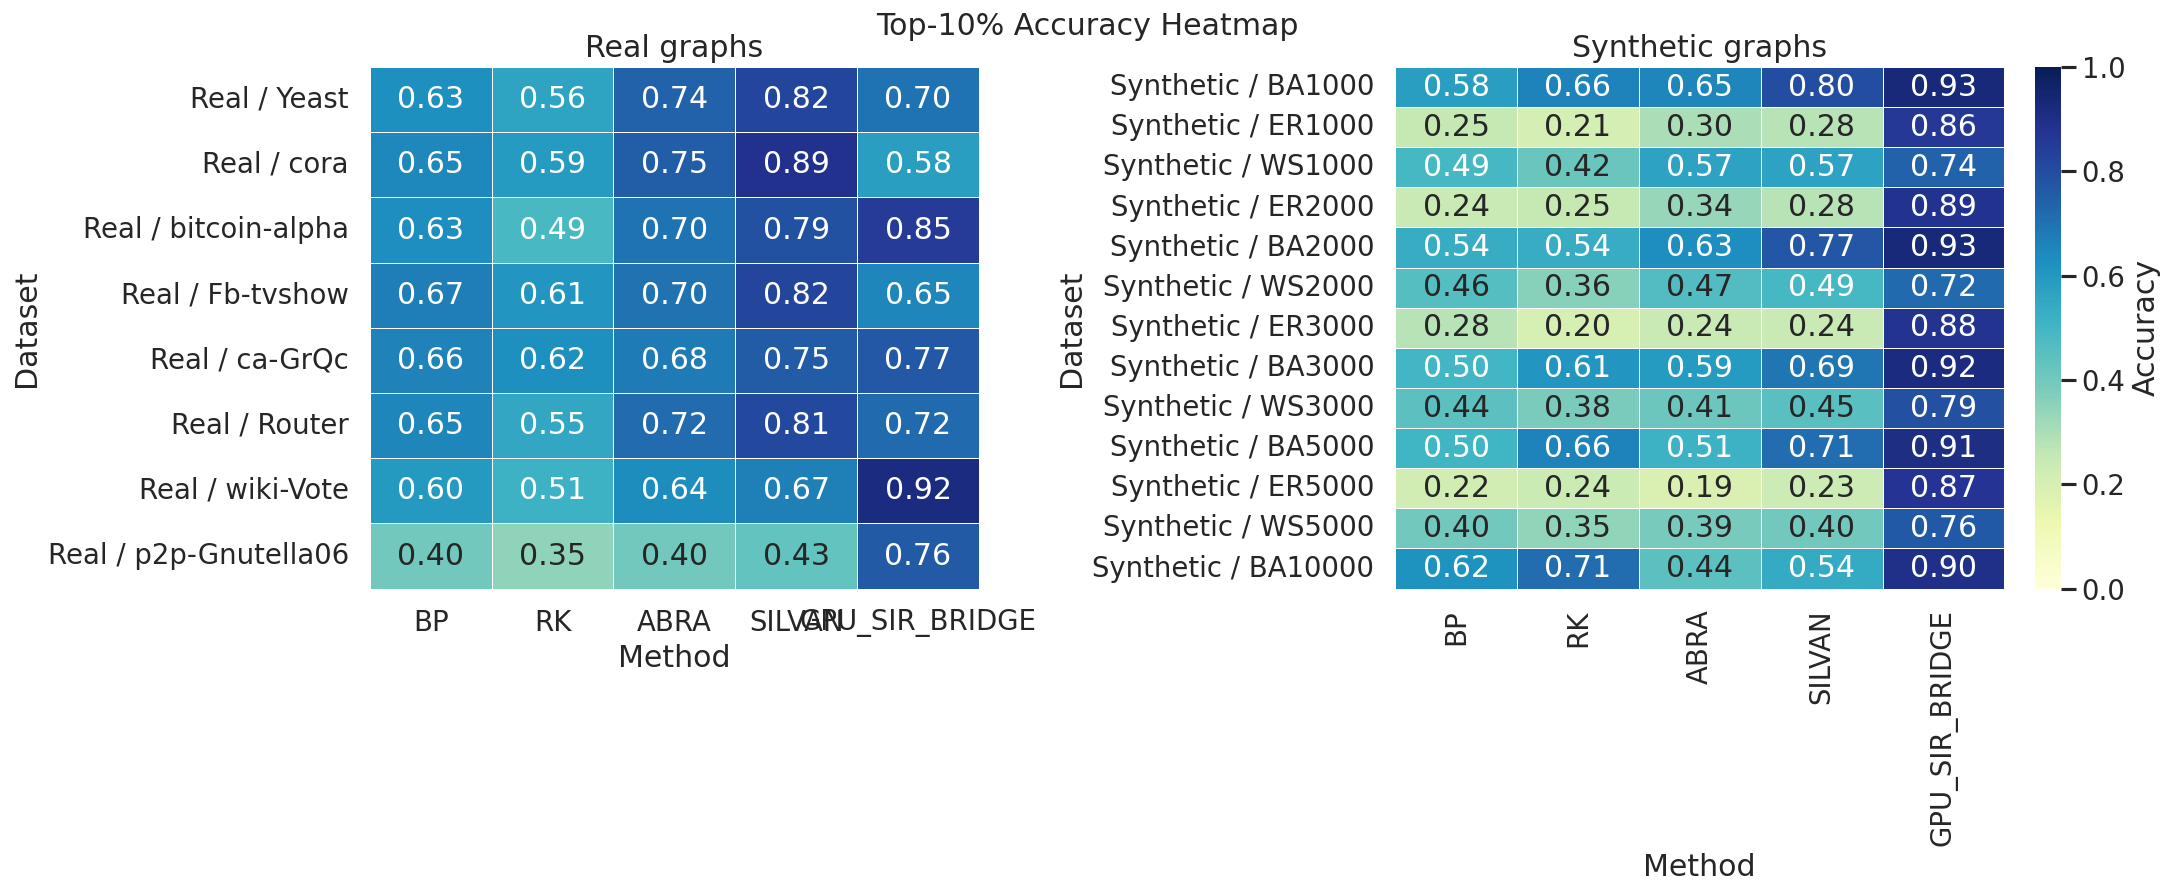

In [3]:
acc_plot_df = acc_df[["graph_name", "graph_source", "num_nodes", "num_edges", "dataset_label", *APPROX_METHOD_ORDER]].copy()
fig, _ = plot_split_heatmaps(
    acc_plot_df,
    columns=APPROX_METHOD_ORDER,
    title="Top-10% Accuracy Heatmap",
    cmap="YlGnBu",
    vmin=0.0,
    vmax=1.0,
    fmt=".2f",
    cbar_label="Accuracy",
)
fig.savefig(FIG_DIR / "acc_heatmap.png", bbox_inches="tight")
plt.show()


## Spearman heatmaps

The first plot shows `EXACT` vs each approximation method across all datasets.
The second plot summarizes the average pairwise Spearman correlation over all datasets.

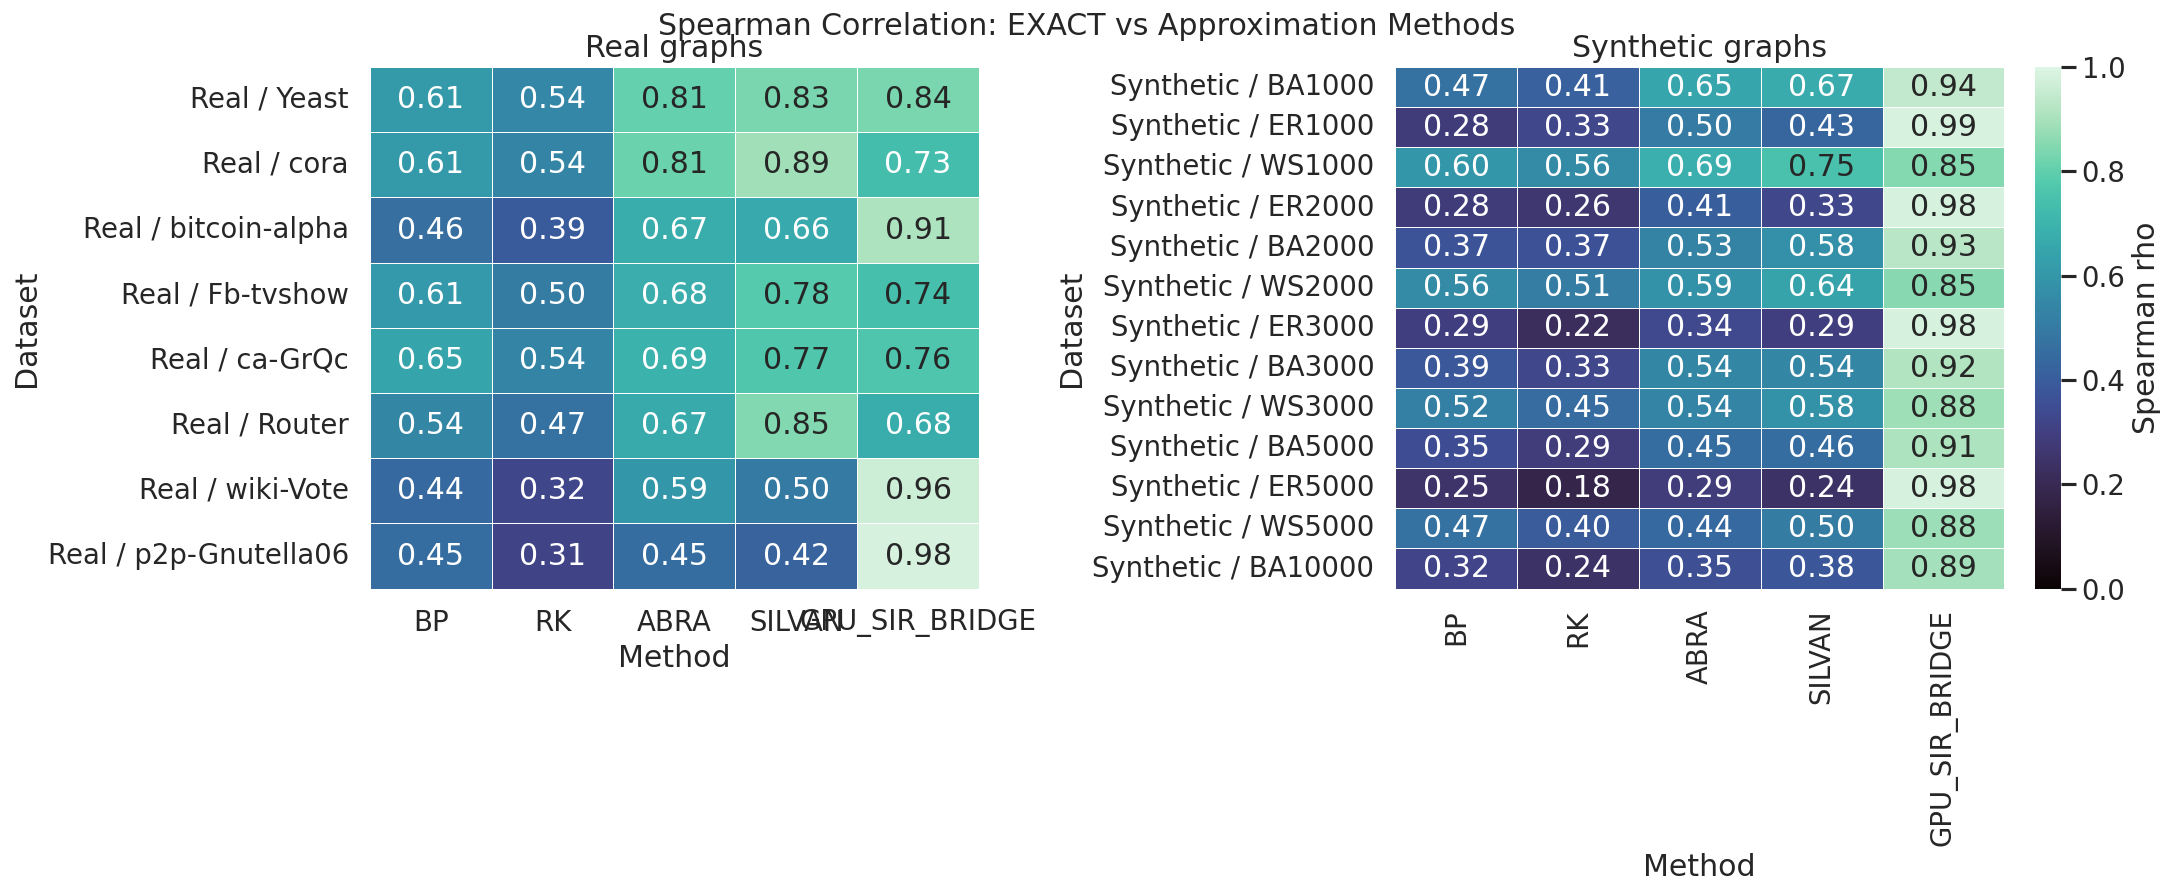

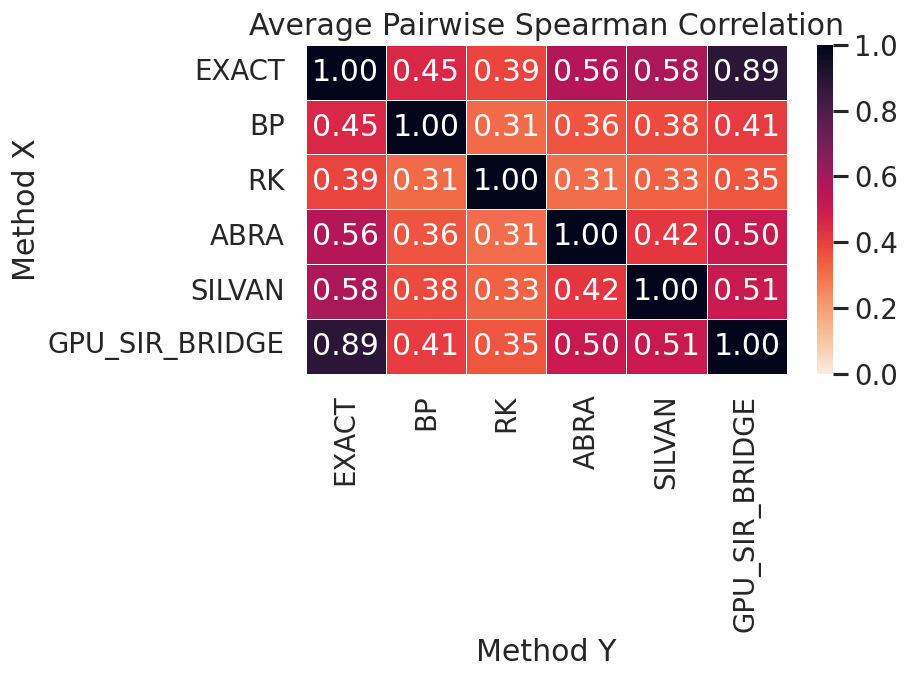

In [4]:
exact_vs_method = spearman_df.query("method_x == 'EXACT' and method_y != 'EXACT'").copy()
exact_vs_method = exact_vs_method.rename(columns={"method_y": "method"})
exact_heatmap = (
    exact_vs_method
    .pivot_table(index=["graph_source", "graph_name", "num_nodes", "dataset_label"], columns="method", values="spearman")
    .reset_index()
)

fig, _ = plot_split_heatmaps(
    exact_heatmap,
    columns=APPROX_METHOD_ORDER,
    title="Spearman Correlation: EXACT vs Approximation Methods",
    cmap="mako",
    vmin=0.0,
    vmax=1.0,
    fmt=".2f",
    cbar_label="Spearman rho",
)
fig.savefig(FIG_DIR / "spearman_exact_heatmap.png", bbox_inches="tight")
plt.show()

pairwise_mean = (
    spearman_df.groupby(["method_x", "method_y"], as_index=False)["spearman"]
    .mean()
    .pivot(index="method_x", columns="method_y", values="spearman")
    .reindex(index=METHOD_ORDER, columns=METHOD_ORDER)
)

plt.figure(figsize=(8, 6))
sns.heatmap(pairwise_mean, cmap="rocket_r", vmin=0.0, vmax=1.0, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Average Pairwise Spearman Correlation")
plt.xlabel("Method Y")
plt.ylabel("Method X")
plt.tight_layout()
plt.savefig(FIG_DIR / "spearman_pairwise_mean_heatmap.png", bbox_inches="tight")
plt.show()


## Runtime comparison

The heatmap includes `EXACT` and all approximation methods. Since runtimes vary a lot, the color scale is logarithmic.
The bar chart shows the average speedup over `EXACT`.

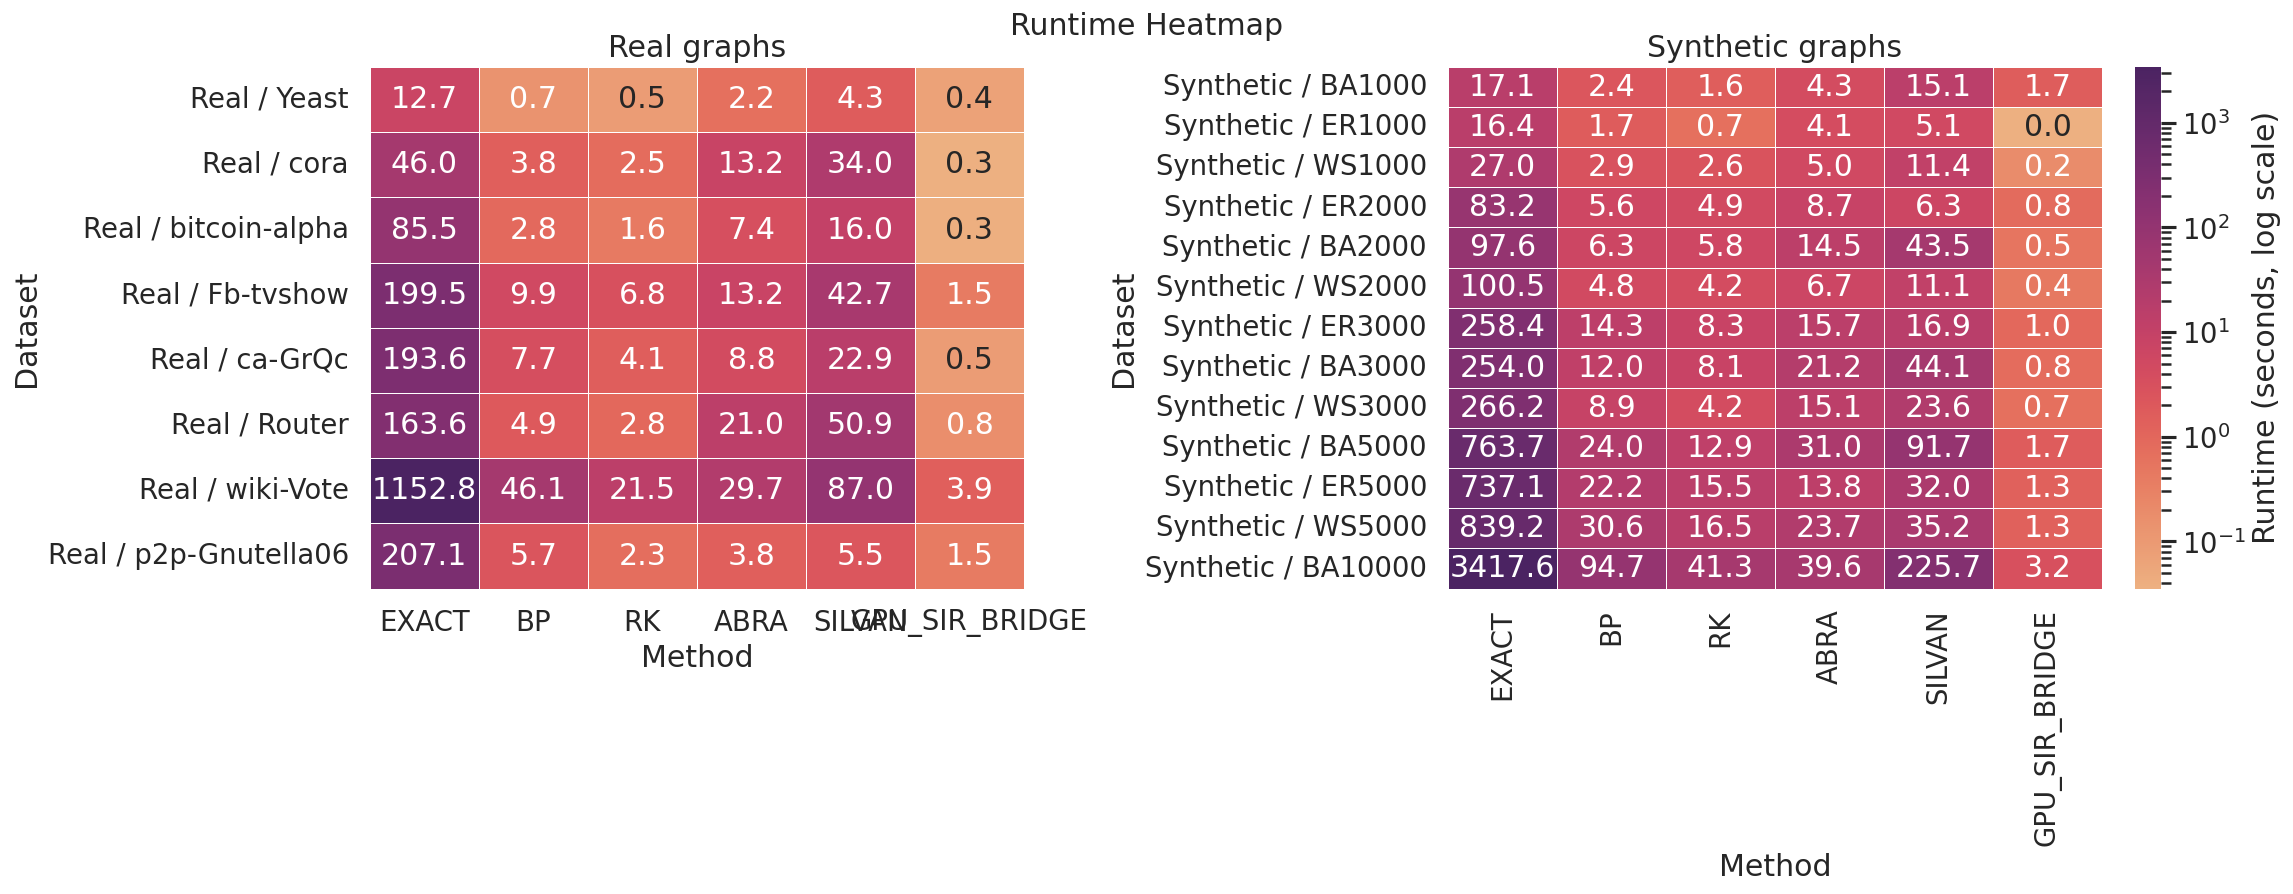

/tmp/ipykernel_4114806/1005868618.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


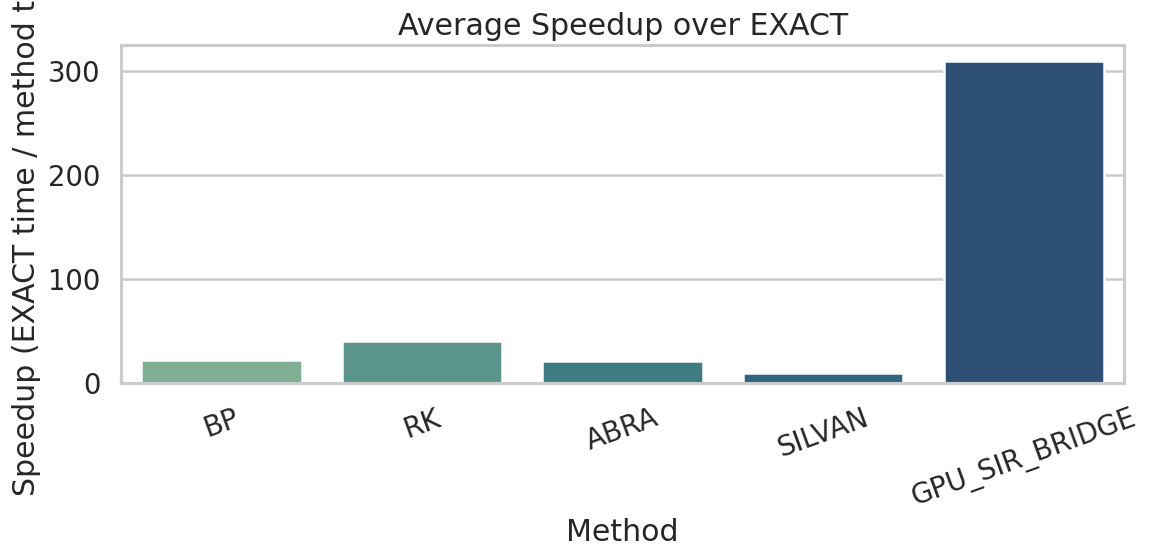

,method,speedup
2,GPU_SIR_BRIDGE,309.396414
3,RK,40.221608
1,BP,22.676800
0,ABRA,21.433719
4,SILVAN,10.024325


In [5]:
runtime_heatmap_df = time_df.copy()
runtime_heatmap_df["EXACT"] = runtime_heatmap_df["exact_time"]

ordered_labels = ordered_dataset_labels(runtime_heatmap_df)
max_rows = max((runtime_heatmap_df["graph_source"] == source).sum() for source in SOURCE_ORDER)
fig_height = max(4.5, 0.55 * max_rows)
fig, axes = plt.subplots(1, 2, figsize=(19, fig_height), constrained_layout=True)

for idx, source in enumerate(SOURCE_ORDER):
    ax = axes[idx]
    subset = runtime_heatmap_df[runtime_heatmap_df["graph_source"] == source].copy()
    if subset.empty:
        ax.set_axis_off()
        continue

    subset["dataset_label"] = pd.Categorical(subset["dataset_label"], categories=ordered_labels, ordered=True)
    subset = subset.sort_values("dataset_label")
    heatmap_data = subset.set_index("dataset_label")[METHOD_ORDER]

    sns.heatmap(
        heatmap_data,
        ax=ax,
        cmap="flare",
        annot=True,
        fmt=".1f",
        linewidths=0.5,
        norm=LogNorm(vmin=max(heatmap_data.min().min(), 1e-3), vmax=heatmap_data.max().max()),
        cbar=(idx == len(SOURCE_ORDER) - 1),
        cbar_kws={"label": "Runtime (seconds, log scale)"} if idx == len(SOURCE_ORDER) - 1 else None,
    )
    ax.set_title(SOURCE_TITLE[source])
    ax.set_xlabel("Method")
    ax.set_ylabel("Dataset")

fig.suptitle("Runtime Heatmap", y=1.02, fontsize=18)
fig.savefig(FIG_DIR / "runtime_heatmap.png", bbox_inches="tight")
plt.show()

speedup_df = time_df.copy()
for method in APPROX_METHOD_ORDER:
    speedup_df[method] = speedup_df["exact_time"] / speedup_df[method]

speedup_long = speedup_df.melt(
    id_vars=["graph_name", "graph_source", "dataset_label", "num_nodes"],
    value_vars=APPROX_METHOD_ORDER,
    var_name="method",
    value_name="speedup",
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=speedup_long,
    x="method",
    y="speedup",
    order=APPROX_METHOD_ORDER,
    estimator=np.mean,
    errorbar=None,
    palette="crest",
)
plt.title("Average Speedup over EXACT")
plt.xlabel("Method")
plt.ylabel("Speedup (EXACT time / method time)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIG_DIR / "runtime_speedup_bar.png", bbox_inches="tight")
plt.show()

speedup_summary = (
    speedup_long.groupby("method", as_index=False)["speedup"]
    .mean()
    .sort_values("speedup", ascending=False)
)
speedup_summary
